![imagen](cardiovascular_diseases.jpg)

# Introduction

The objective of this notebook is to apply decision tree models with hyperparameter tuning to predict cardiovascular disease (CVD) risk, comparing their generalization performance using clinical and lifestyle patient data.

Throughout this exercise, the following tasks will be addressed:

1. Decision Tree Models:
   - Build a baseline decision tree classifier (without hyperparameter tuning)
   - Build a tuned decision tree classifier using GridSearchCV with the specified search space

2. Model Evaluation: Apply both models to the test set and derive:
   - Confusion matrix
   - Classification report (precision, recall, f1-score)

3. Feature Importance Analysis: Generate feature importance tables for both models and compare the most important variables selected by each

4. Key Questions to Answer:
   - Which model has better generalization performance?
   - What are the seven most important features for each model?
   - Are there differences in feature selection between models? If so, what could explain these differences?
   - Based on the best model, how could these insights guide lifestyle change recommendations for high-risk patients?

This exercise will provide hands-on experience with hyperparameter tuning for decision trees, model comparison, feature importance interpretation, and translating analytical findings into actionable medical recommendations for cardiovascular risk management.

# 1. Import libraries

In [61]:
# Data handling
import pandas as pd

# To prepare
from sklearn.preprocessing import LabelEncoder

# To create the decision tree
from sklearn.tree import DecisionTreeClassifier 

# To split the dataset into training and test sets
from sklearn.model_selection import train_test_split

# To evaluate the model
from sklearn.metrics import accuracy_score

# For performance reporting using ranking metrics 
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

# For hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# For cross-validation
from sklearn.model_selection import KFold 

# Visualization libraries
import matplotlib.pyplot as plt

from ydata_profiling import ProfileReport

# 2. Load data

In [62]:
data=pd.read_csv('enfermedad_cardiovascular_data.csv', sep=',', encoding = 'utf-8')

In [63]:
data.shape

(67976, 13)

In [64]:
data.head()

,Id,Edad,Género,Altura,Peso,Presion sistólica,Presión diastólica,Colesterol,Glucosa,Fumador,Alcohol,Activo,ECV
0,0,53,M,168,62.0,110,80,Normal,Normal,NO,NO,SI,NO
1,1,58,F,156,85.0,140,90,Muy elevado,Normal,NO,NO,SI,SI
2,2,54,F,165,64.0,130,70,Muy elevado,Normal,NO,NO,NO,SI
3,3,50,M,169,82.0,150,100,Normal,Normal,NO,NO,SI,SI
4,4,50,F,156,56.0,100,60,Normal,Normal,NO,NO,NO,NO


In [65]:
data.dtypes

Id                      int64
Edad                    int64
Género                 object
Altura                  int64
Peso                  float64
Presion sistólica       int64
Presión diastólica      int64
Colesterol             object
Glucosa                object
Fumador                object
Alcohol                object
Activo                 object
ECV                    object
dtype: object

# 3. EDA

In [66]:
data.describe()

,Id,Edad,Altura,Peso,Presion sistólica,Presión diastólica
count,67976.000000,67976.000000,67976.000000,67976.000000,67976.000000,67976.000000
mean,49954.764858,55.627913,164.555829,74.392564,126.731611,81.458794
std,28841.186196,7.047183,7.751991,14.032135,16.706251,9.624818
min,0.000000,31.000000,140.000000,48.000000,70.000000,50.000000
25%,24989.750000,50.000000,159.000000,65.000000,120.000000,80.000000
50%,49986.000000,56.000000,165.000000,72.000000,120.000000,80.000000
75%,74842.250000,61.000000,170.000000,82.000000,140.000000,90.000000
max,99999.000000,68.000000,198.000000,183.000000,240.000000,190.000000


In [67]:
profile = ProfileReport(
    data, 
    title="Analysis Report - Dataset Data",
    explorative=True  
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 24.78it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# 4. Data preparation

In [8]:
missing_values = data.isnull().sum().sum()
print(missing_values)

54


In [9]:
data_t = data
data_t=data_t.dropna()

In [10]:
data_t.shape

(67922, 13)

In [11]:
data_t = pd.get_dummies(data_t, columns=['Género','Colesterol', 'Glucosa', 'Fumador', 'Alcohol', 'Activo',])

In [12]:
encoding = LabelEncoder()

In [13]:
data_t['ECV']=encoding.fit_transform(data_t['ECV'])

In [14]:
data_t.head()

,Id,Edad,Altura,Peso,Presion sistólica,Presión diastólica,ECV,Género_F,Género_M,Colesterol_Elevado,...,Colesterol_Normal,Glucosa_Elevado,Glucosa_Muy elevado,Glucosa_Normal,Fumador_NO,Fumador_SI,Alcohol_NO,Alcohol_SI,Activo_NO,Activo_SI
0,0,53,168,62.0,110,80,0,False,True,False,...,True,False,False,True,True,False,True,False,False,True
1,1,58,156,85.0,140,90,1,True,False,False,...,False,False,False,True,True,False,True,False,False,True
2,2,54,165,64.0,130,70,1,True,False,False,...,False,False,False,True,True,False,True,False,True,False
3,3,50,169,82.0,150,100,1,False,True,False,...,True,False,False,True,True,False,True,False,False,True
4,4,50,156,56.0,100,60,0,True,False,False,...,True,False,False,True,True,False,True,False,True,False


In [15]:
data_t = data_t.drop(['Id'], axis=1)

In [16]:
data_t.shape

(67922, 20)

# 5. Model Building

In [17]:
Y=data_t['ECV']
X=data_t.drop(['ECV'], axis=1)

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

### 5.1 Hyperparameter-free model

In [40]:
%matplotlib inline

In [41]:
Tree = DecisionTreeClassifier(criterion='entropy', random_state = 0)
Tree

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [42]:
Tree = Tree.fit(X_train,Y_train)

In [43]:
y_pred = Tree.predict(X_test)

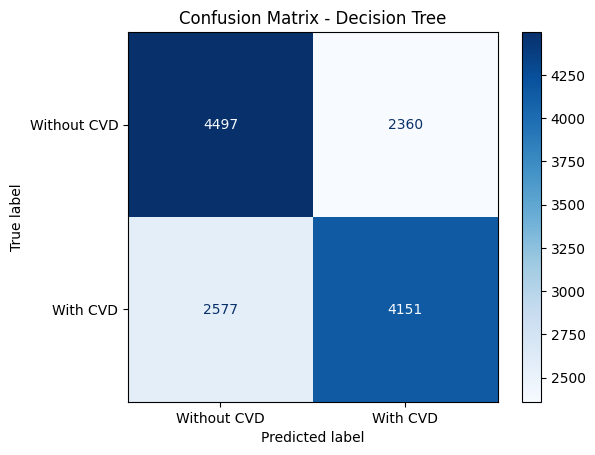

In [45]:
ConfusionMatrixDisplay.from_estimator(Tree, X_test, Y_test, 
                                       display_labels=['Without CVD', 'With CVD'],
                                       cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

In [47]:
print('Accuracy: %.2f' % accuracy_score(Y_test, y_pred))
print("Recall: {}".format(recall_score(Y_test,y_pred)))
print("Precision: {}".format(precision_score(Y_test,y_pred)))
print("Score F1: {}".format(f1_score(Y_test,y_pred)))

Accuracy: 0.64
Recall: 0.6169738406658739
Precision: 0.6375364767316848
Score F1: 0.6270866379635924


In [48]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.66      0.65      6857
           1       0.64      0.62      0.63      6728

    accuracy                           0.64     13585
   macro avg       0.64      0.64      0.64     13585
weighted avg       0.64      0.64      0.64     13585



In this case, balancing may not be necessary, thanks to the values of the classes

### 5.2 Model with hyperparameter search

In [49]:
partitions = KFold(n_splits=10, shuffle=True, random_state = 0)

In [50]:
param_grid = {'criterion':['gini', 'entropy'],'max_depth':[4,6,8,10],'min_samples_split':[2, 3, 4, 5]}

In [51]:
tree_hyperparameters = DecisionTreeClassifier(random_state=0)

In [52]:
best_model = GridSearchCV(tree_hyperparameters, param_grid, cv=partitions)
best_model.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [4, 6, ...], 'min_samples_split': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramet

In [53]:
best_model.best_params_

{'criterion': 'gini', 'max_depth': 8, 'min_samples_split': 2}

In [54]:
final_model = best_model.best_estimator_

y_pred = final_model.predict(X_test)
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6857
           1       0.76      0.67      0.71      6728

    accuracy                           0.73     13585
   macro avg       0.73      0.73      0.73     13585
weighted avg       0.73      0.73      0.73     13585



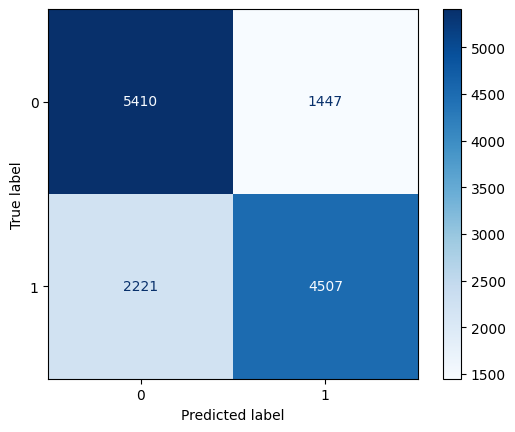

In [55]:
ConfusionMatrixDisplay.from_estimator(final_model, X_test, Y_test, cmap='Blues')

# 6. Results

In [56]:
importance = Tree.feature_importances_
importance_hyperparameters = final_model.feature_importances_

In [57]:
Importance_Attribute = pd.DataFrame(data={"Atributo": X_train.columns,"Importance normal model": importance, "Importance hyperparameters model": importance_hyperparameters})
Importance_Attribute

,Atributo,Importance normal model,Importance hyperparameters model
0,Edad,0.162807,0.124617
1,Altura,0.217596,0.011285
2,Peso,0.233772,0.023253
3,Presion sistólica,0.192694,0.733277
4,Presión diastólica,0.057483,0.012312
5,Género_F,0.013949,0.002518
6,Género_M,0.014303,0.000206
7,Colesterol_Elevado,0.007475,0.006501
8,Colesterol_Muy elevado,0.014113,0.063593
9,Colesterol_Normal,0.012218,0.001223


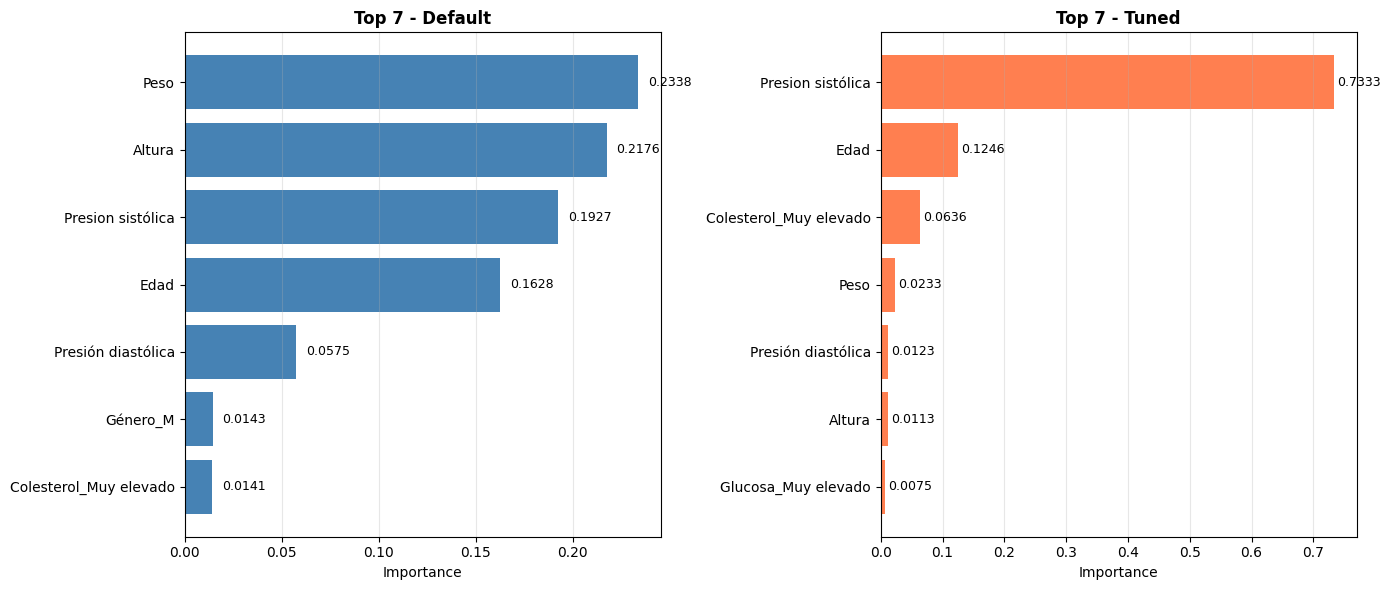

In [59]:
def plot_importance(model, title, color, ax):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(7)
    ax.barh(imp.index, imp.values, color=color)
    ax.set_xlabel('Importance')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(imp.values):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_importance(Tree, 'Top 7 - Default', 'steelblue', axes[0])
plot_importance(final_model, 'Top 7 - Tuned', 'coral', axes[1])
plt.tight_layout()
plt.show()

The tuned model concentrates predictive power on systolic blood pressure as the dominant feature, while the default model distributes importance more evenly across weight, height, and blood pressure.

In [60]:
y_pred_default = Tree.predict(X_test)

y_pred_tuned = final_model.predict(X_test)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Default Model': [
        accuracy_score(Y_test, y_pred_default),
        precision_score(Y_test, y_pred_default),
        recall_score(Y_test, y_pred_default),
        f1_score(Y_test, y_pred_default)
    ],
    'Tuned Model': [
        accuracy_score(Y_test, y_pred_tuned),
        precision_score(Y_test, y_pred_tuned),
        recall_score(Y_test, y_pred_tuned),
        f1_score(Y_test, y_pred_tuned)
    ]
})

print(comparison.round(4))

      Metric  Default Model  Tuned Model
0   Accuracy         0.6366       0.7300
1  Precision         0.6375       0.7570
2     Recall         0.6170       0.6699
3   F1-Score         0.6271       0.7108


The model with hyperparameters (using GridSearchCV) offers better generalization performance, with:

- +9.34% higher accuracy (73.0% vs 63.7%)
- +11.95% higher precision (75.7% vs 63.8%)
- +8.37% higher F1-Score (71.1% vs 62.7%)

These results indicate that hyperparameter tuning successfully improved the model's ability to generalize to unseen data, making it more reliable for cardiovascular disease risk prediction.

Hyperparameter tuning (specifically `max_depth`, `min_samples_split`, and `criterion`) changed how the tree splits data:

1. The tuned model identified systolic blood pressure as the most critical predictor, learning a simpler and more clinically interpretable rule: elevated blood pressure is the main driver of cardiovascular disease risk.
2. Anthropometric variables (weight, height) lost importance as the tuned model found simpler, more efficient splits using blood pressure

### Key Takeaway

The tuned model suggests that hypertension management should be the cornerstone of CVD prevention strategies, rather than focusing primarily on weight or height alone. Patients with elevated systolic blood pressure represent the highest priority group for clinical intervention.